In [33]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from build_dataset import build_dataset
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Taking the words of the corpus

In [34]:
words_corpus = open("names.txt", "r").read().splitlines()
words_corpus[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [35]:
print(f"The total len of the words of the corpus are {len(words_corpus)}")

The total len of the words of the corpus are 32033


#### Build the vocabulary of characters and mapping to/from integers

In [36]:
chars_corpus = sorted(list(set(''.join(words_corpus)))) #Set so it doesnt repeat the words
print(f"This are the words in the corpus{chars_corpus} and the len {len(chars_corpus)}")

This are the words in the corpus['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'] and the len 26


In [37]:
stoi = {letter:index+1 for index, letter in enumerate(chars_corpus)} #This for making the letters and the index
stoi['.'] = 0 #Its the first index its going to be .
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [45]:
itos = {index:letter for letter,index in stoi.items()}
print(len(itos))

27


#### Build the Dataset

In [44]:
import random
block_size_context = 3  #the context length: how many characters 
                        # the model sees to predict the next one
                        # e.g. "_ _ _ -> ?"


random.seed(42) #This is for reproducibility
random.shuffle(words_corpus)
n1 = int(0.80 * len(words_corpus)) #This is for the training set
n2 = int(0.90 * len(words_corpus)) #This is for the validation set and the test set

X_training, Y_training = build_dataset(words_corpus=words_corpus[:n1],block_size=block_size_context, stoi=stoi) #until 80%
X_validation, Y_validation = build_dataset(words_corpus=words_corpus[n1:n2], block_size=block_size_context, stoi=stoi) #10 for validation
X_test, Y_test = build_dataset(words_corpus=words_corpus[n2:], block_size=block_size_context, stoi=stoi)#10 for test

torch.Size([182512, 3]) torch.Size([182512])
torch.Size([22860, 3]) torch.Size([22860])
torch.Size([22774, 3]) torch.Size([22774])


In [48]:



embedding_dim = 10

hidden_size_first_layer = block_size_context * embedding_dim #This is because we have the number of neurons is the embedding dim * number of layers


hidden_size_second_layer = 200
batch_size = 32
lenght_characters_dataset = len(itos)
generator = torch.Generator().manual_seed(2147483647)


In [49]:

C = torch.randn((lenght_characters_dataset, embedding_dim), generator=generator) #The look out matrix, is the matrix with the embeddings
W1 = torch.randn((hidden_size_first_layer, hidden_size_second_layer), generator=generator) # 30 neurons first layers, 200 neurons second layer
b1 = torch.randn((hidden_size_second_layer), generator=generator) # The bias is always the next layer
W2 = torch.randn((hidden_size_second_layer, lenght_characters_dataset)) #The 200 neurons of second layer, the number of outputs
b2 = torch.randn((lenght_characters_dataset), generator=generator)

parameters = [C, W1, b1, W2, b2]

In [50]:
print(f"The total number of parameters {sum(p.nelement() for p in parameters)}")

The total number of parameters 11897


In [51]:
for p in parameters:
    p.requires_grad = True #Functions so the gradients are active to being changed and when loss.backward() there is going to be and update

In [54]:
lre = torch.linspace(-3, 0 , 1000) #To create from range -3 to 0 samples
lrs = 10**lre #To normalize it so we have the learning lare brom 0.0010 to 1

In [56]:
lr_index = []
loss_index = []
step_index = []
EPOCHS = 200000

In [ ]:
idx = 98869
contexto = X_training[idx]
print(contexto)  
siguiente = Y_training[idx]
print(siguiente)
print([itos[i.item()] for i in contexto], '->', itos[siguiente.item()])

In [84]:
for index in range(EPOCHS):
    #Creating the minibatch
    ix = torch.randint(0, X_training.shape[0], (batch_size,)) #Cada iteración → 32 índices random de TODO el dataset → El mismo ejemplo puede aparecer en muchas iteraciones, o no aparecer nunca en miles de pasos
    
    #Forward Pass
    embedding = C[X_training[ix]]
    hidden_layer_tahn = torch.tanh(embedding.view(-1, 30) @ W1 + b1)  #View -> (32, 3, 10) → (32, 30)
    logits = hidden_layer_tahn @ W2 + b2 #(32, 27) its the one to see how weel it does the prediction
    loss = F.cross_entropy(logits, Y_training[ix])
    
    #BackWard pass
    for p in parameters:
        p.grad = None #Transform the gradients to 0 so it can be update
    loss.backward()

    #update
    lr = 0.1 if index < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lr_index.append(lre[index])
    step_index.append(index)
    loss_index.append(loss.log10().item())

print(loss.item())


2.4958837032318115


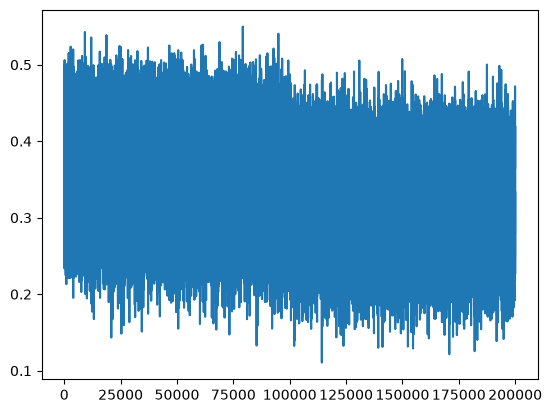

In [81]:
plt.plot(step_index, loss_index)

In [85]:
#Training Loss
embedding = C[X_training]

hidden_layer_tahn = torch.tanh(embedding.view(-1, 30) @ W1 + b1)  #View -> (32, 3, 10) → (32, 30)
logits = hidden_layer_tahn @ W2 + b2 #(32, 27) its the one to see how weel it does the prediction
loss = F.cross_entropy(logits, Y_training)
loss

tensor(2.0629, grad_fn=<NllLossBackward0>)

In [87]:
#Training Loss
embedding = C[X_validation]

hidden_layer_tahn = torch.tanh(embedding.view(-1, 30) @ W1 + b1)  #View -> (32, 3, 10) → (32, 30)
logits = hidden_layer_tahn @ W2 + b2 #(32, 27) its the one to see how weel it does the prediction
loss = F.cross_entropy(logits, Y_validation)
loss

tensor(2.1289, grad_fn=<NllLossBackward0>)

In [88]:
#Training Loss
embedding = C[X_test]

hidden_layer_tahn = torch.tanh(embedding.view(-1, 30) @ W1 + b1)  #View -> (32, 3, 10) → (32, 30)
logits = hidden_layer_tahn @ W2 + b2 #(32, 27) its the one to see how weel it does the prediction
loss = F.cross_entropy(logits, Y_test)
loss

tensor(2.1408, grad_fn=<NllLossBackward0>)

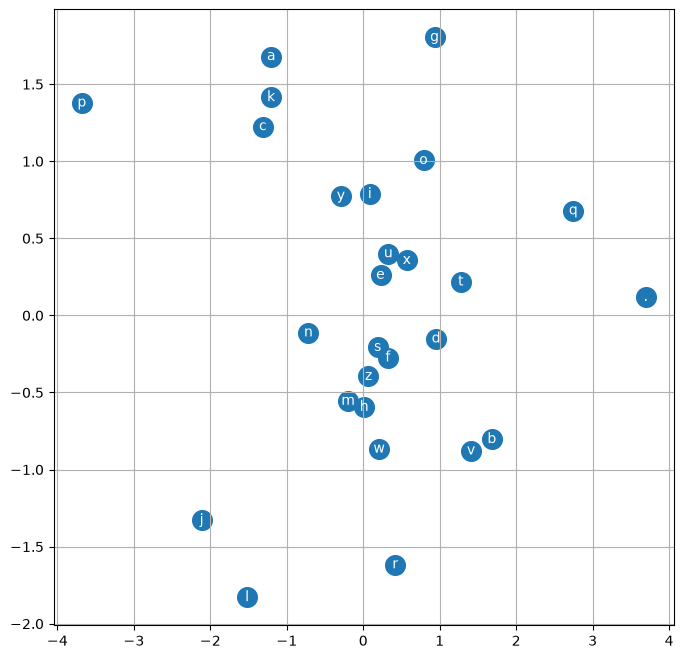

In [89]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [90]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size_context # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmaizabelle.
khi.
miliana.
cassanden.
jazhitlalee.
rhy.
kaeli.
nellara.
chriivia.
leigh.
ham.
jord.
quintis.
lilea.
jadiq.
waverly.
jarisi.
jaxen.
dura.
med.
